In [1]:
import numpy as np

In [2]:
dp = np.load('/common/ganesanv/tlab/data/cvpr24-medsam/XRay/Chest-Xray-Masks-and-Labels/XRay_Chest-Xray-Masks-and-Labels_CHNCXR_0001_0.npz')

In [5]:
dp['imgs']

dp['gts']

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2919, 3000), dtype=uint8)

In [6]:



np.max(dp['gts'])

np.uint8(3)

In [7]:
dp['imgs']

array([[[59, 59, 59],
        [48, 48, 48],
        [39, 39, 39],
        ...,
        [38, 38, 38],
        [39, 39, 39],
        [39, 39, 39]],

       [[59, 59, 59],
        [49, 49, 49],
        [41, 41, 41],
        ...,
        [36, 36, 36],
        [38, 38, 38],
        [38, 38, 38]],

       [[60, 60, 60],
        [49, 49, 49],
        [45, 45, 45],
        ...,
        [35, 35, 35],
        [33, 33, 33],
        [37, 37, 37]],

       ...,

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]]], shape=(2919, 3000, 3), dtype=uint8)

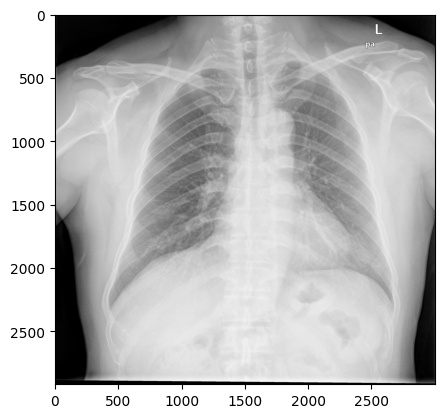

In [8]:
import matplotlib.pyplot as plt
plt.imshow(dp['imgs'])

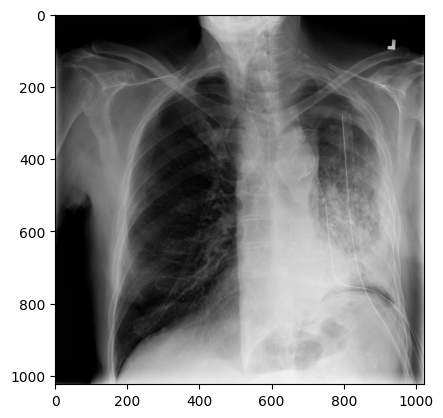

In [ ]:
dp2 = np.load('/common/ganesanv/tlab/data/cvpr24-medsam/XRay/Pneumothorax-Masks/XRay_Pneumothorax-Masks_0_test_1.npz')

plt.imshow(dp2['imgs'])







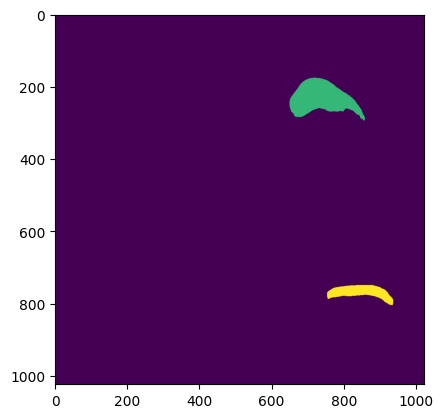

In [12]:
plt.imshow(dp2['gts'])

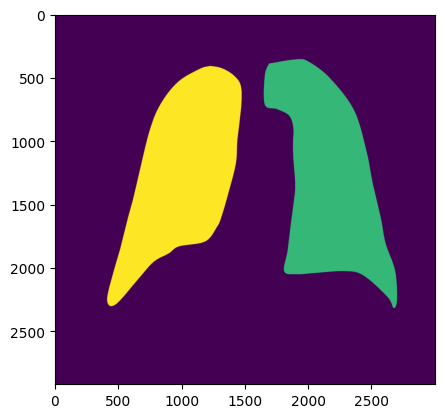

In [9]:
plt.imshow(dp['gts'])

In [ ]:
import pickle
import os
import urllib

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
from scipy import signal

DINOV3_GITHUB_LOCATION = "facebookresearch/dinov3"

if os.getenv("DINOV3_LOCATION") is not None:
    DINOV3_LOCATION = os.getenv("DINOV3_LOCATION")
else:
    DINOV3_LOCATION = DINOV3_GITHUB_LOCATION

print(f"DINOv3 location set to {DINOV3_LOCATION}")

In [ ]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_NAME = MODEL_DINOV3_VITL

model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model=MODEL_NAME,
    source="local" if DINOV3_LOCATION != DINOV3_GITHUB_LOCATION else "github",
)
model.cuda()